# Основные концепции Machine Learning. Домашняя работа

In [ ]:
### Тут нужно сделать импорты всех необходимых библиотек ###

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # для отрисовки 3D проекции

matplotlib.rc("font", size=18) # для увеличения шрифта подписей графиков

In [ ]:
### Здесь требуется загрузить датасет phones.csv ###

In [4]:
phones = pd.read_csv('phones.csv')
phones.head()

,disk,os,price,year
0,64,Android,7256,2016
1,128,Android,7623,2015
2,64,Android,1916,2010
3,512,iOS,15045,2017
4,16,Android,4478,2013


In [ ]:
### Опционально: используя matplotlib, можно сделать визуализацию загруженного датасета ###

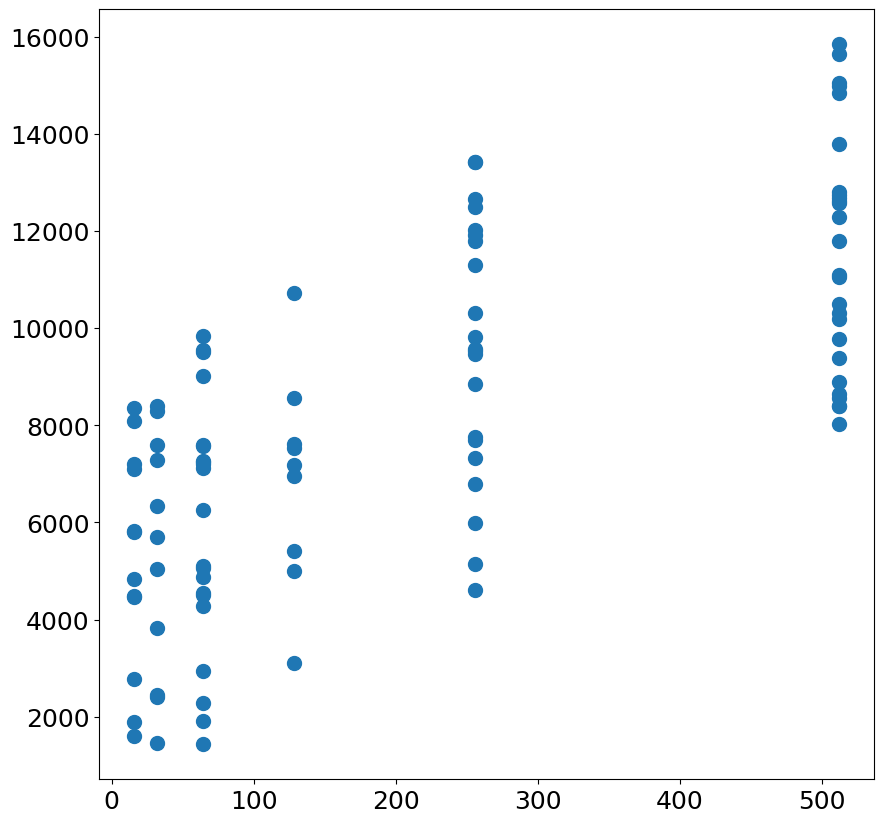

In [5]:
fig = plt.figure(figsize=(10, 10)) # создаем картинку
ax = plt.axes()

# помещаем точки на график
ax.scatter(phones["disk"], phones["price"], s=100)

# отображаем картинку
plt.show()

Задание 1: обучить модель регрессии

In [7]:
### Тут нужно выгрузить в соответствующие переменные выбранные признаки ###
X = phones[["disk"]]
y = phones["price"]

In [ ]:
### Здесь следует запустить процесс обучения ###
### и продемонстрировать работоспобность обученной модели ###

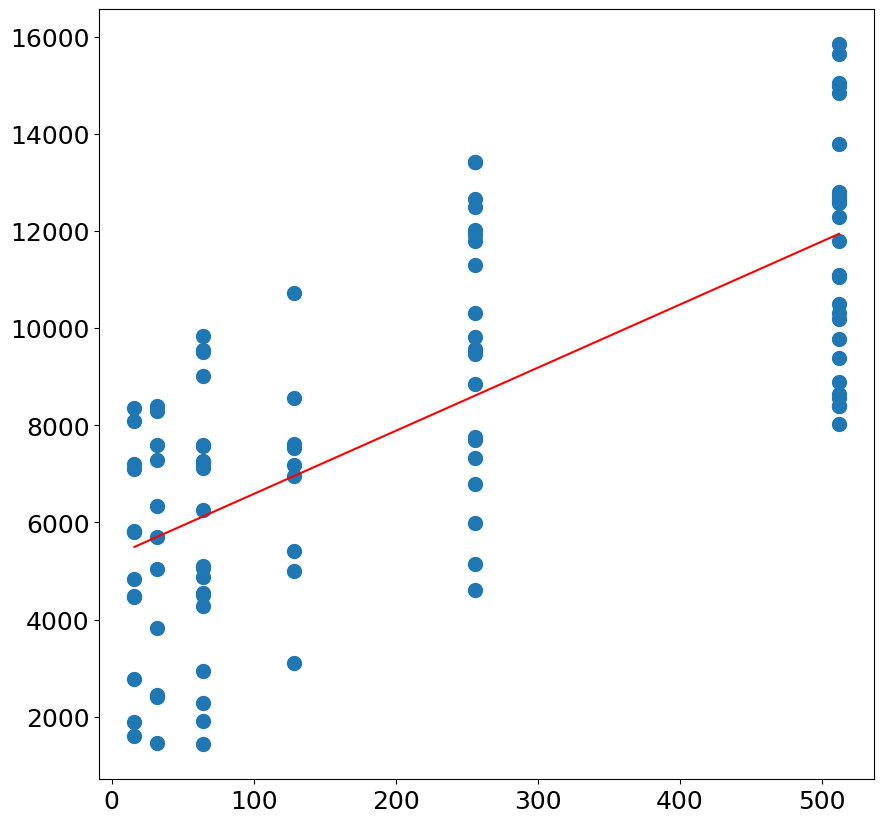

In [8]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X, y)

# вытаскиваем нужные коэффициенты
[b] = reg.coef_
a = reg.intercept_

# создаем функцию для предсказания цены дома
def reg_prediction(dim_1):
    return a + b * dim_1

fig = plt.figure(figsize=(10, 10)) # создаем картинку
ax = plt.axes()

# помещаем точки на график
ax.scatter(phones["disk"], phones["price"], s=100)
# помещаем предсказания
ax.plot([X.disk.min(), X.disk.max()], [reg_prediction(X.disk.min()), reg_prediction(X.disk.max())], c="red")

# отображаем картинку
plt.show()

Задание 2: обучить модель классификации

In [9]:
### Тут нужно выгрузить в соответствующие переменные выбранные признаки ###
X = phones[["disk", "year"]]
y = phones["price"]

In [ ]:
### Здесь следует запустить процесс обучения ###
### и продемонстрировать работоспобность обученной модели ###

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

# создаем классификатор
cl = DecisionTreeClassifier().fit(X, y)
print(export_text(cl))

|--- feature_1 <= 2017.50
|   |--- feature_0 <= 24.00
|   |   |--- feature_1 <= 2010.50
|   |   |   |--- class: 1599
|   |   |--- feature_1 >  2010.50
|   |   |   |--- feature_1 <= 2011.50
|   |   |   |   |--- class: 1890
|   |   |   |--- feature_1 >  2011.50
|   |   |   |   |--- feature_1 <= 2012.50
|   |   |   |   |   |--- class: 2780
|   |   |   |   |--- feature_1 >  2012.50
|   |   |   |   |   |--- feature_1 <= 2013.50
|   |   |   |   |   |   |--- class: 4473
|   |   |   |   |   |--- feature_1 >  2013.50
|   |   |   |   |   |   |--- feature_1 <= 2014.50
|   |   |   |   |   |   |   |--- class: 4832
|   |   |   |   |   |   |--- feature_1 >  2014.50
|   |   |   |   |   |   |   |--- feature_1 <= 2015.50
|   |   |   |   |   |   |   |   |--- class: 5814
|   |   |   |   |   |   |   |--- feature_1 >  2015.50
|   |   |   |   |   |   |   |   |--- feature_1 <= 2016.50
|   |   |   |   |   |   |   |   |   |--- class: 7091
|   |   |   |   |   |   |   |   |--- feature_1 >  2016.50
|   |   |   |  

Задание 3: обучить модель кластеризации

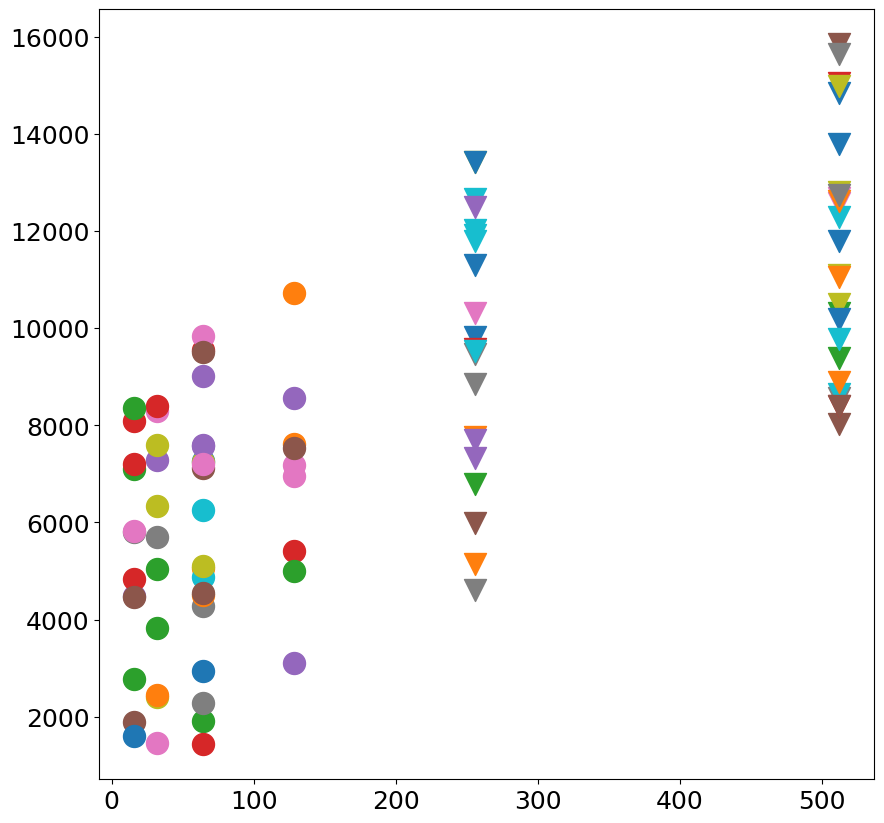

In [11]:
### Тут нужно выгрузить в соответствующие переменные выбранные признаки ###
fig = plt.figure(figsize=(10, 10)) # создаем картинку

markers = {"Android": "o", "iOS": "v"}
for d1, d2, l in zip(phones.disk, phones.price, phones.os):
    plt.scatter(d1, d2, s=250, marker=markers[l])

# отображаем картинку
plt.show()
X = phones[["disk", "price"]]

In [ ]:
### Здесь следует запустить процесс обучения ###
### и продемонстрировать работоспобность обученной модели ###

In [15]:
from sklearn.cluster import KMeans
# создаем модель для кластеризации
clust = KMeans(n_clusters=2).fit(X)
clust.cluster_centers_

array([[  116.8       ,  5784.78333333],
       [  368.        , 11601.65      ]])

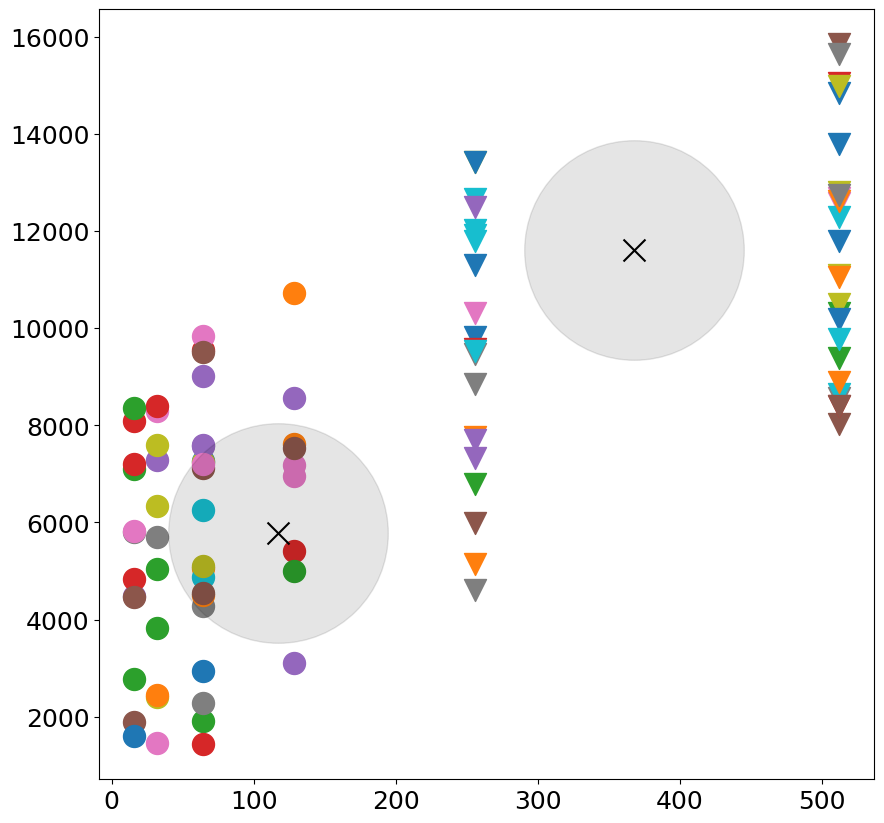

In [16]:
# смотрим центры кластеров
[c1, c2] = clust.cluster_centers_
fig = plt.figure(figsize=(10, 10)) # создаем картинку

markers = {"Android": "o", "iOS": "v"}
for d1, d2, l in zip(phones.disk, phones.price, phones.os):
    plt.scatter(d1, d2, s=250, marker=markers[l])

# добавляем информацию о центрах кластеров
plt.scatter(c1[0], c1[1], s=250, marker="x", c="black")
plt.scatter(c1[0], c1[1], s=250 * 1e2, c="black", alpha=0.1)

plt.scatter(c2[0], c2[1], s=250, marker="x", c="black")
plt.scatter(c2[0], c2[1], s=250 * 1e2, c="black", alpha=0.1)

# отображаем картинку
plt.show()